In [1]:
run = "j"

In [2]:
import sys
sys.path.append("../../src/ml")

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=../../output/ml/j/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from ../../output/ml/j/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=../../output/ml/j/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from ../../output/ml/j/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Initialised
[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote ../../../output/images/ml/j/process/h1o_3x3_cuts_CRY.png


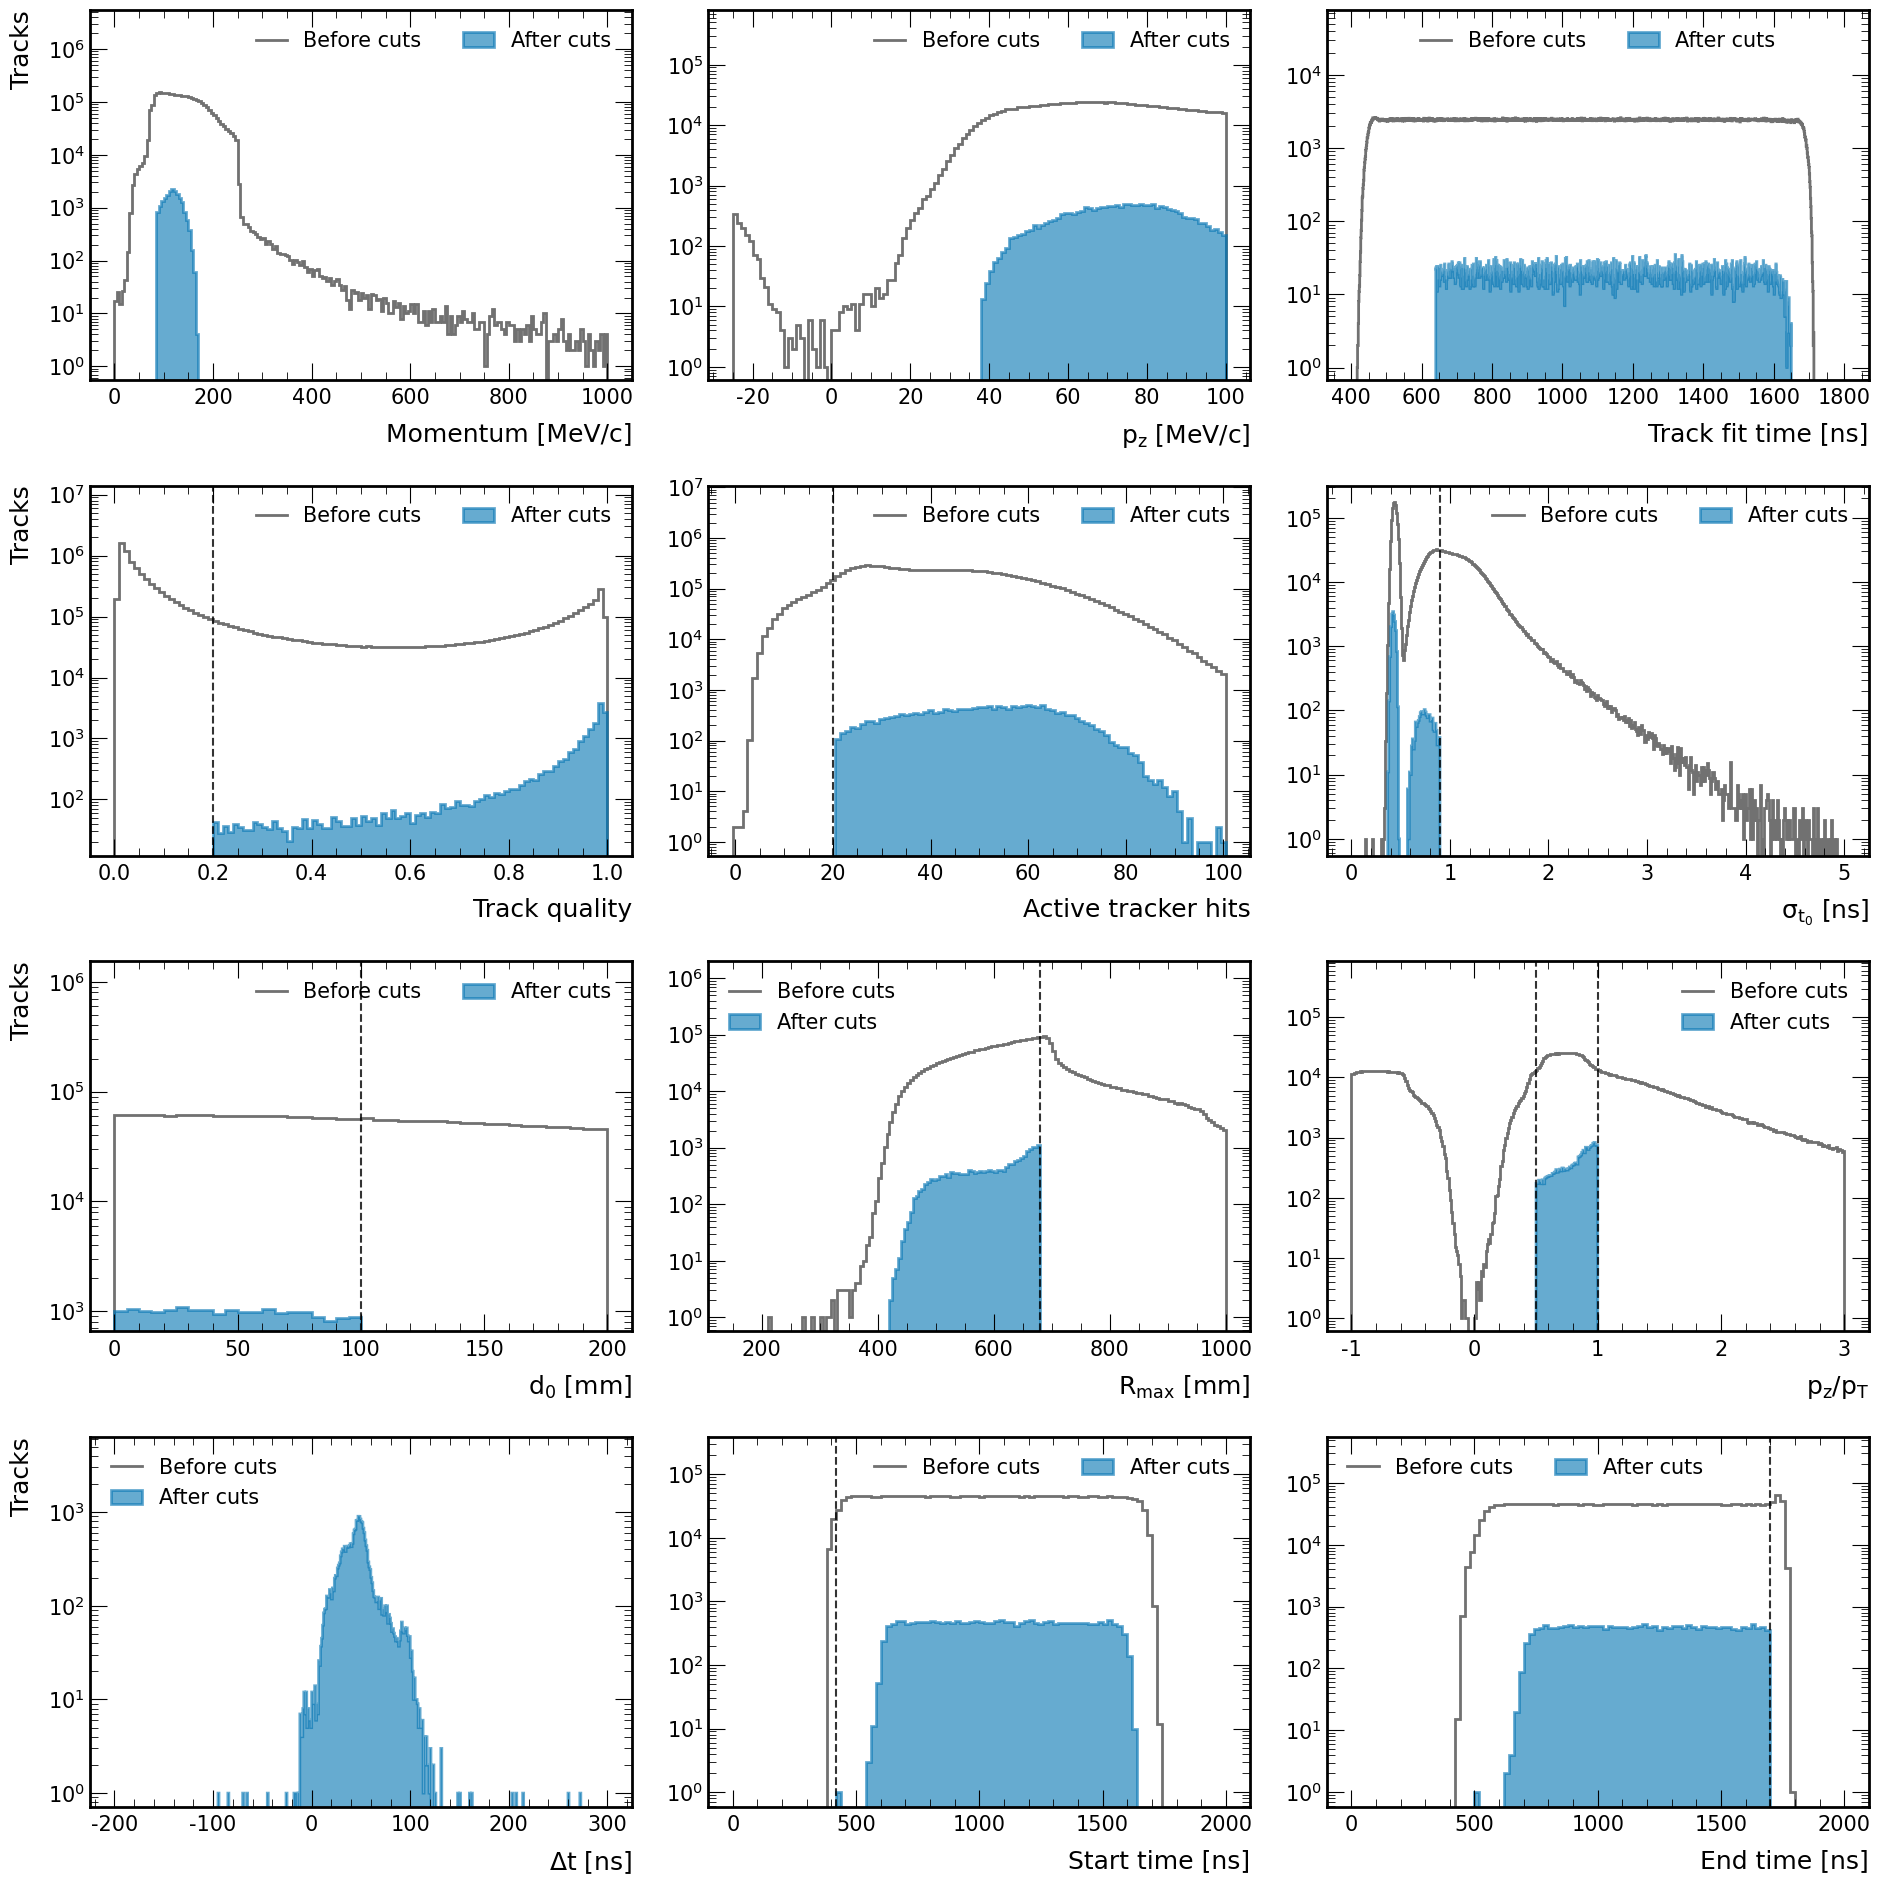

[Plot] [OK] 	Wrote ../../../output/images/ml/j/process/h1o_3x3_cuts_CE_mix.png


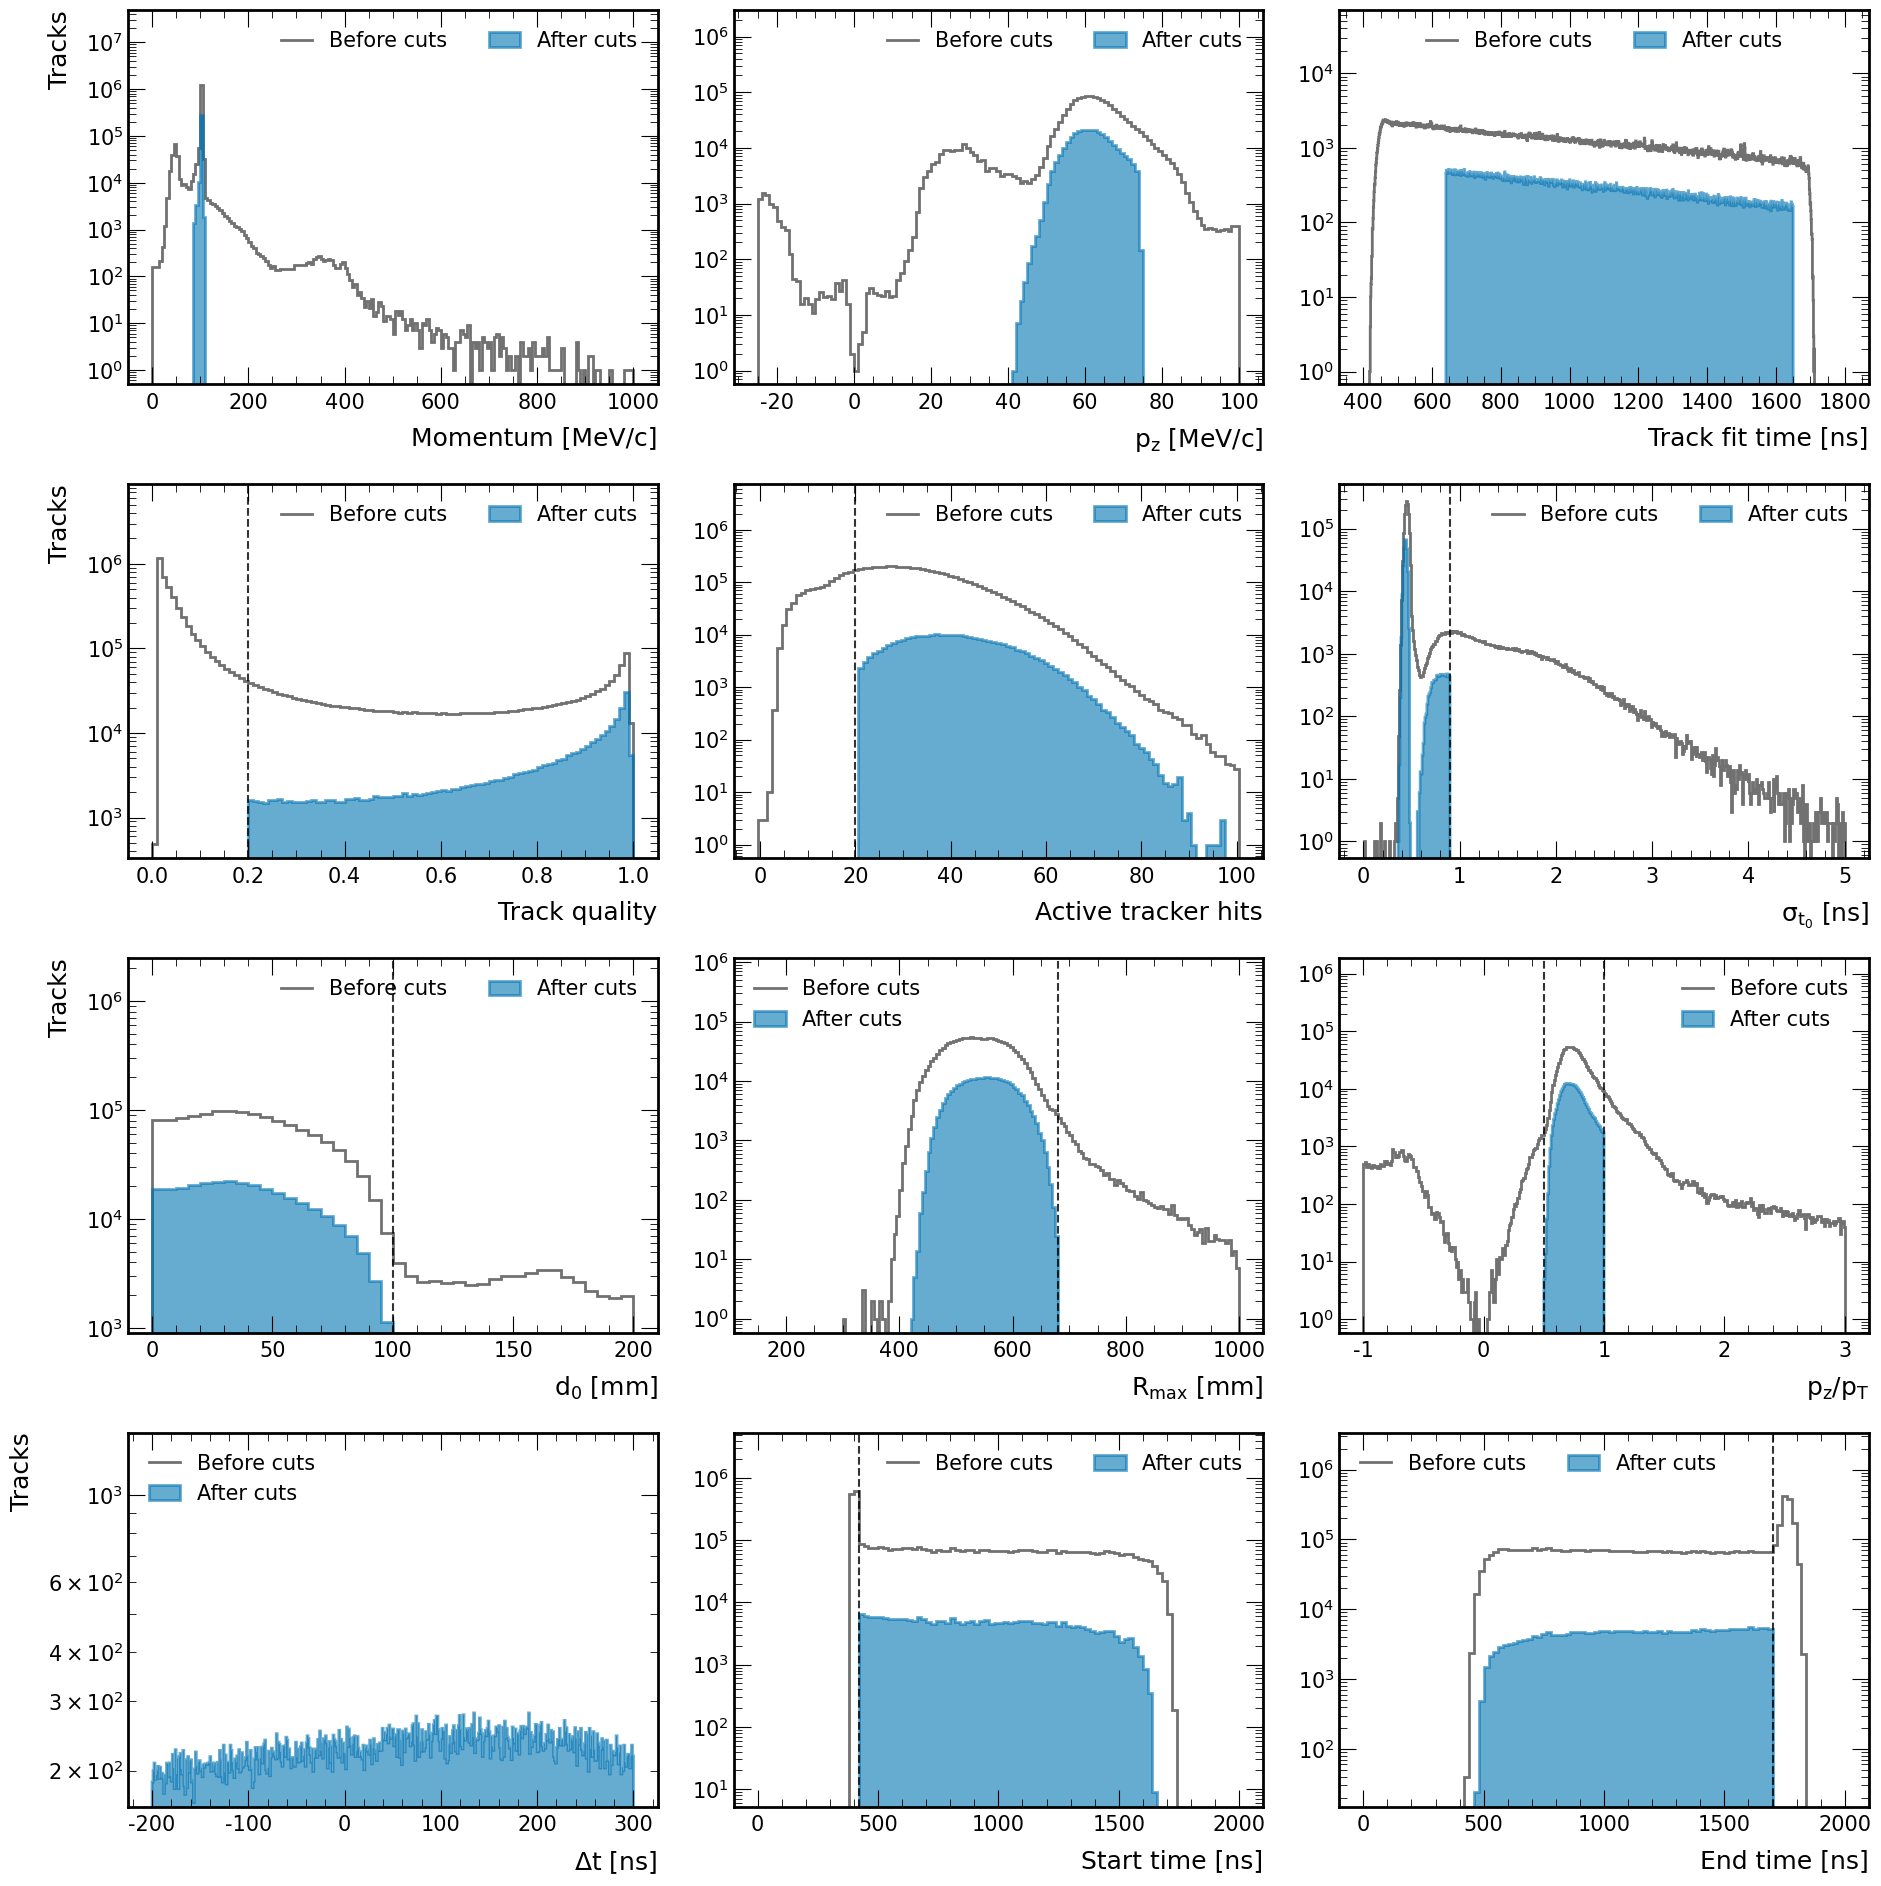

cry:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,2610933,100.000,100.000,No selection applied
1,thru_trk,Preselect,2528178,96.830,96.830,Tracks intersect full tracker
2,is_reco_electron,Preselect,2447193,93.729,96.797,Select electron track hypothesis
3,one_reco_electron,Preselect,2020330,77.380,82.557,One reco electron / event
4,is_downstream,Preselect,1111321,42.564,55.007,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,320059,12.258,28.800,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,253908,9.725,79.332,Track quality > 0.2
7,within_t0,Tracker,203298,7.786,80.068,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,188693,7.227,92.816,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,186108,7.128,98.630,>20 active tracker hits


ce_mix:


,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,1339362,100.000,100.000,No selection applied
1,thru_trk,Preselect,1336977,99.822,99.822,Tracks intersect full tracker
2,is_reco_electron,Preselect,1327509,99.115,99.292,Select electron track hypothesis
3,one_reco_electron,Preselect,1097120,81.914,82.645,One reco electron / event
4,is_downstream,Preselect,1096121,81.839,99.909,Downstream tracks (p_z > 0 through tracker)
5,is_truth_electron,Preselect,1096052,81.834,99.994,Track parents are electrons (truth PID)
6,good_trkqual,Tracker,883129,65.937,80.574,Track quality > 0.2
7,within_t0,Tracker,655442,48.937,74.218,t0 at tracker mid (640 < t_0 < 1650 ns)
8,within_t0err,Tracker,636325,47.510,97.083,Track fit t0 uncertainty (t0err < 0.9 ns)
9,has_hits,Tracker,621990,46.439,97.747,>20 active tracker hits


         Metric    CRY  CE Mix
0         Total  19574  297609
1      Unvetoed     10  264758
2  Fraction [%]  99.95   11.04
[Assemble] [DEBUG] Got sorted and labelled DataFrames
[Assemble] [DEBUG] Got combined dataset
[Assemble] [DEBUG] Columns: Index(['event', 'subrun', 'crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits',
       'nLayers', 'angle', 'timeStart', 'timeEnd', 'sector', 'PEs_per_hit',
       't0', 'd0', 'tanDip', 'maxr', 'mom_mag', 'label'],
      dtype='str')
[Assemble] [DEBUG] Split data (event-level grouping)
[Assemble] [OK] Got ML data


In [3]:
from assemble import AssembleDataset
assembler = AssembleDataset(run=run, cutset_name="MLPreprocess", verbosity=2)
assembler.draw_hists()
cut_flows = assembler.get_cut_flows()
for name, cut_flow in cut_flows.items():
    print(f"{name}:")
    display(cut_flow)
print(assembler.check_dT_window_results())
data = assembler.assemble_dataset()

In [4]:
# Baseline XGBoost
from train import Train
trainer = Train(data)
training_results = trainer.train(
    tag="xgb_baseline",
    save_output=True,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

[Train] [OK] Initialised
[Train] [INFO] Training model: XGBClassifier
  Tag: xgb_baseline
  Random state: 42
  Scale features: True

[Train] [INFO]   Hyperparams: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

[Train] [OK] Training complete!
[Train] [OK] Results saved to ../../output/ml/j/results/xgb_baseline/results.pkl


[AnaModel] [OK] Initialised analyser for model: xgb_baseline
[pyplot] [INFO] Initialised Plot with mu2e.mplstyle and verbosity = 1

  VALIDATION SUMMARY: xgb_baseline

[AnaModel] [INFO] Confusion Matrix:
  TP: 4634, FN: 29
  FP: 22, TN: 84491
[AnaModel] [INFO] ROC AUC:
  Train: 0.9999
  Test:  0.9999
[AnaModel] [INFO] Classification Report:
                precision    recall  f1-score   support

Background (0)       1.00      1.00      1.00     84513
    Signal (1)       1.00      0.99      0.99      4663

      accuracy                           1.00     89176
     macro avg       1.00      1.00      1.00     89176
  weighted avg       1.00      1.00      1.00     89176



Feature importance:
  PEs            : 0.4894
  crv_x          : 0.3359
  nLayers        : 0.1127
  dT             : 0.0268
  crv_y          : 0.0181
  crv_z          : 0.0060
  angle          : 0.0053
  nHits          : 0.0035
  sector         : 0.0023
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline

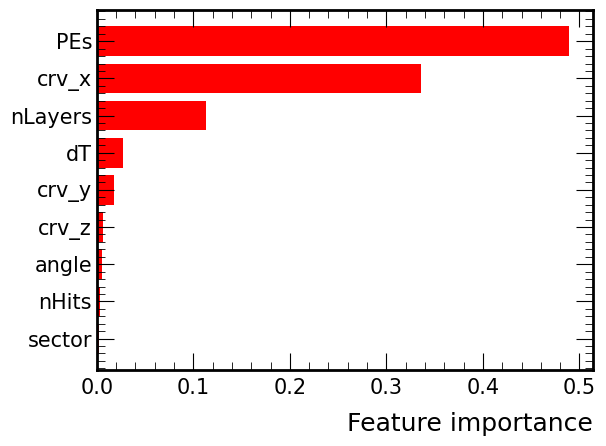

[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline/roc_curve.png


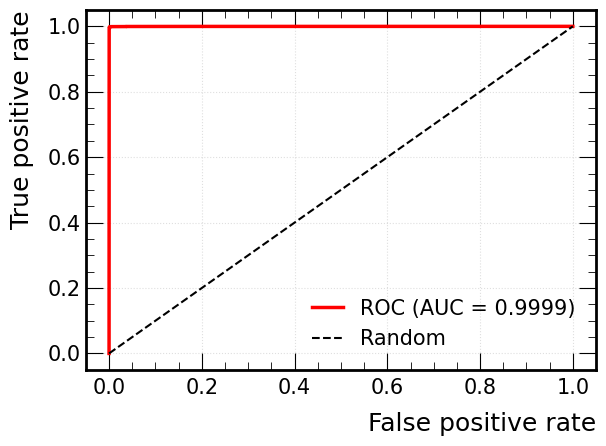

[AnaModel] [INFO] Event-level threshold (target 99.90% veto efficiency):
  Threshold:         0.0452
  Veto efficiency:   99.924%
  Signal efficiency: 99.857%
  Deadtime:          0.143%
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline/threshold_overlay.png
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline/h1_score_distribution.png


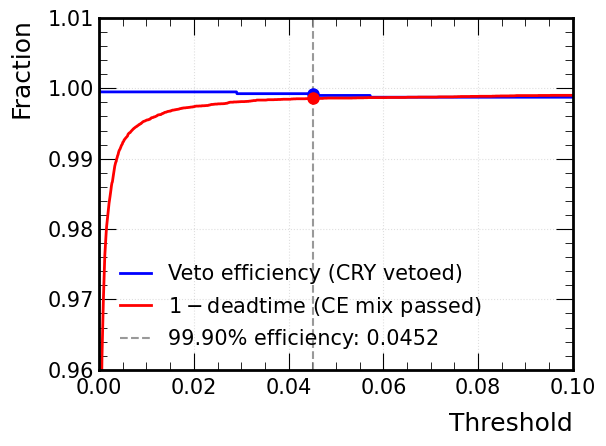

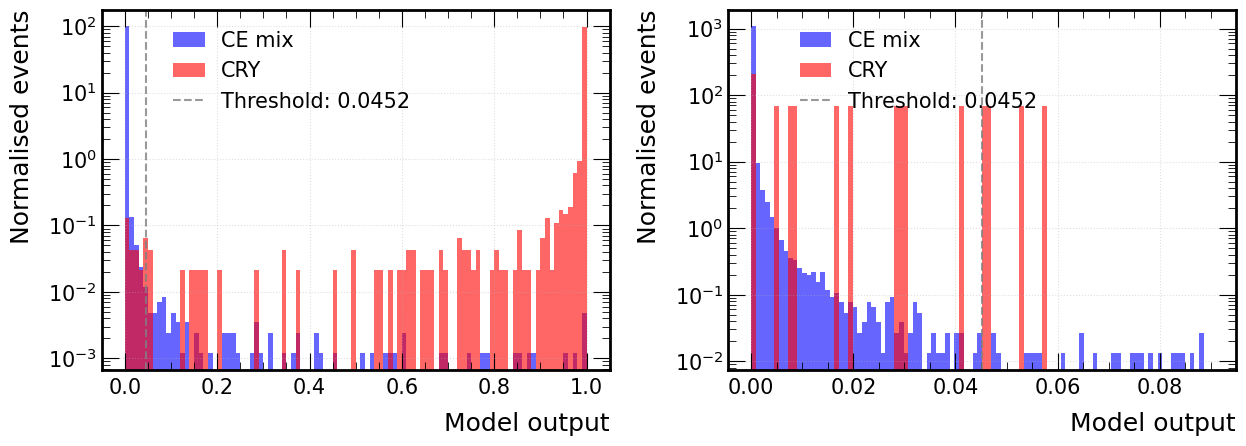

[AnaModel] [INFO] Selected events (score >= 0.0452):
  CRY:    4651
  CE mix: 85
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline/h1_high_score_physics.png


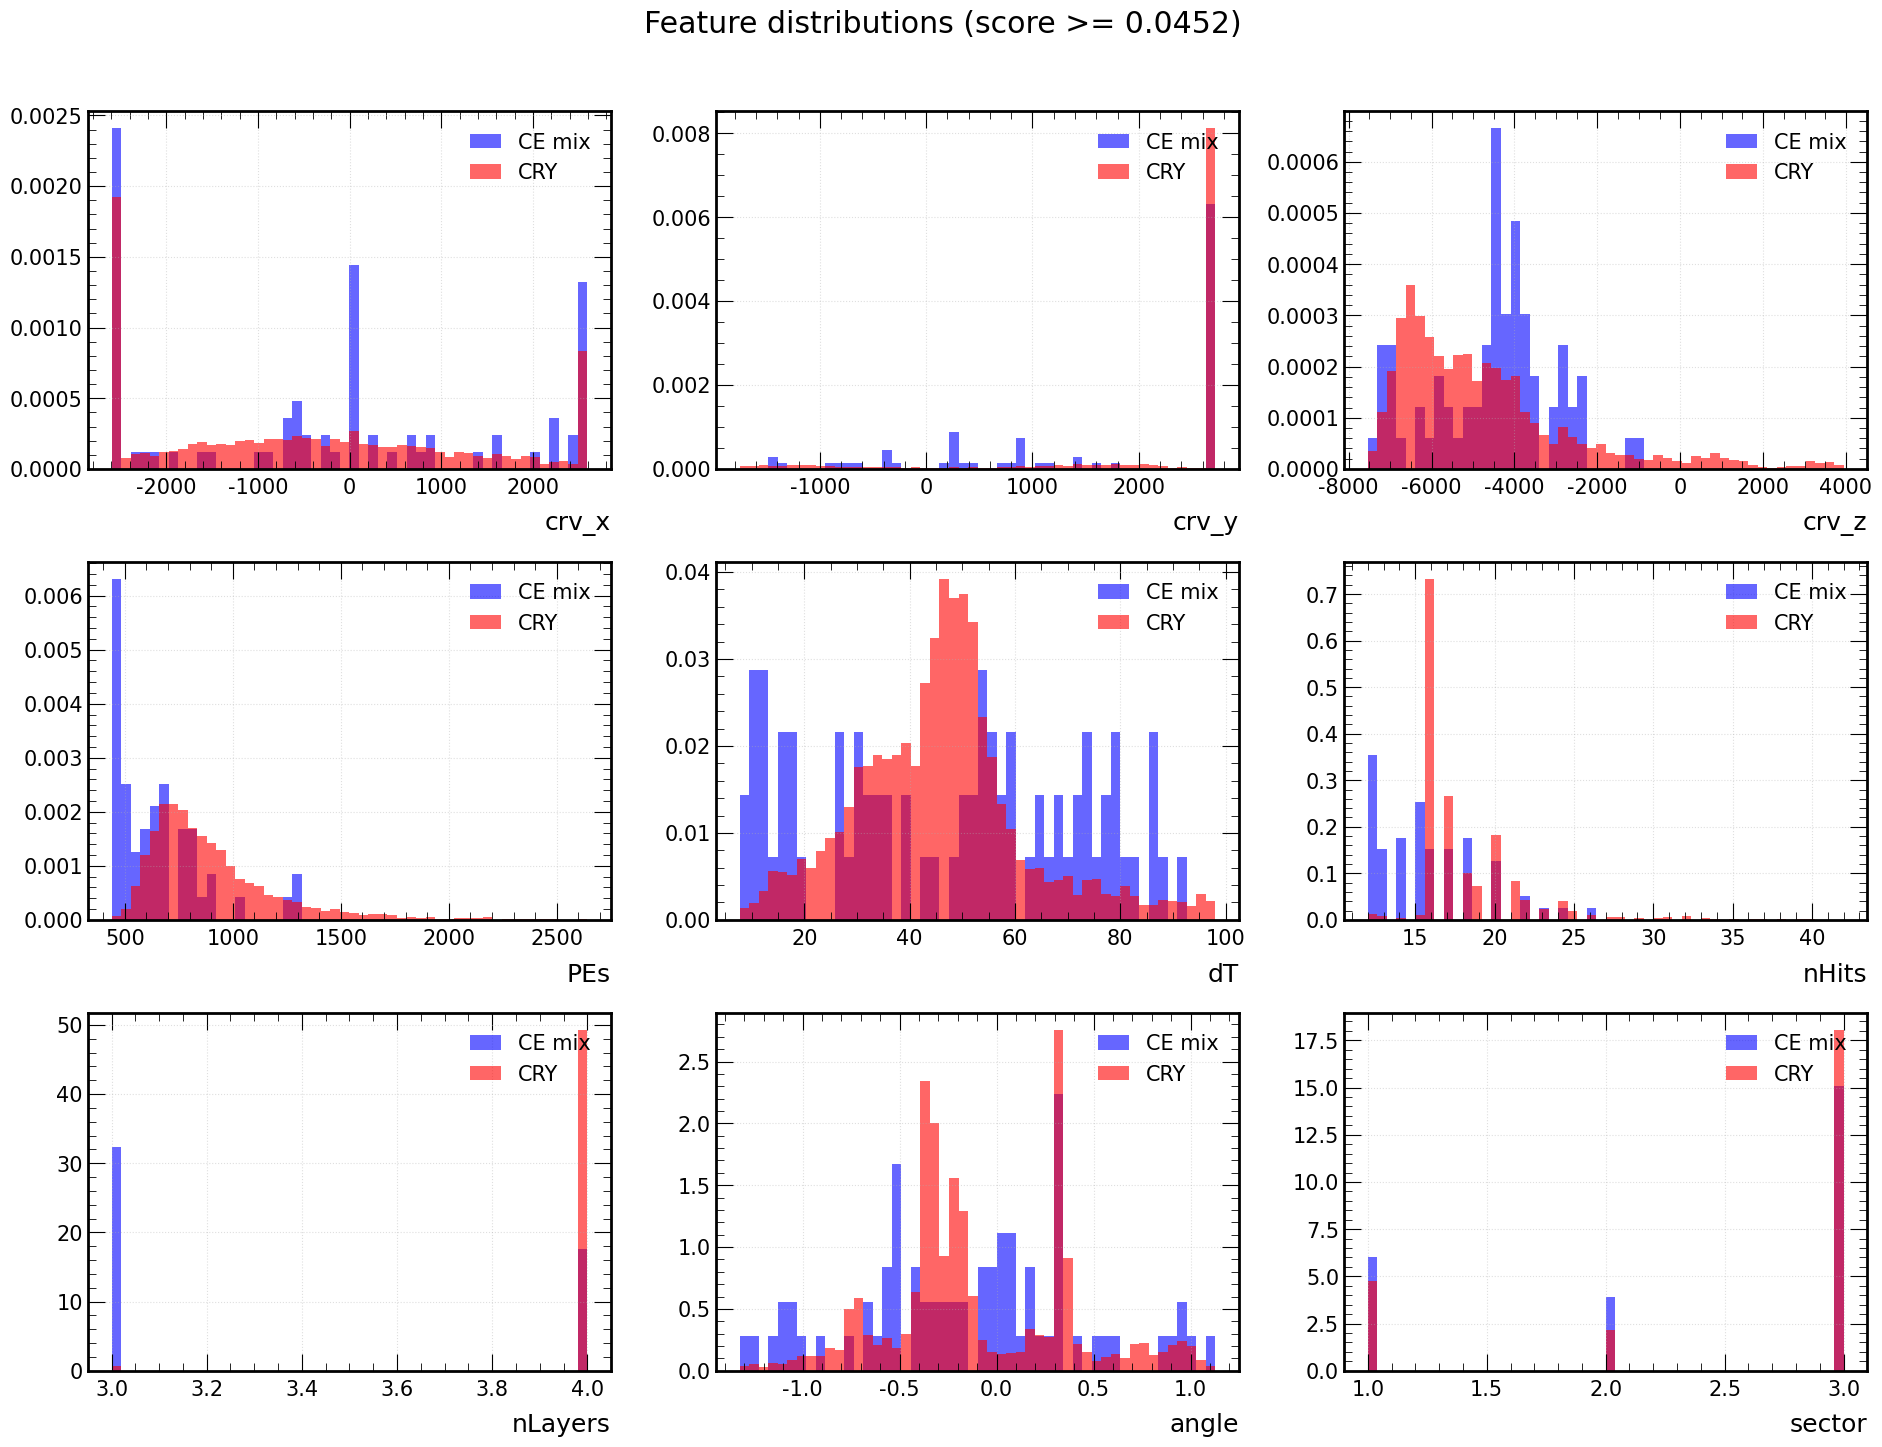

[AnaModel] [INFO] Selected events (score < 0.0452):
  CRY:    12
  CE mix: 84428

Low-score CRY events:
   event  subrun    score
303841.0 40396.0 0.004771
 96378.0 18895.0 0.008343
 91471.0 13087.0 0.007985
328545.0 54267.0 0.028197
107124.0 52416.0 0.030251
  9224.0 20155.0 0.041585
106851.0  3492.0 0.029071
283585.0  4846.0 0.000046
287217.0 24158.0 0.019679
426274.0 76525.0 0.000413
283308.0 35908.0 0.000197
369509.0 63500.0 0.017047

[AnaModel] [OK] Saved low-score CRY events to ../../output/images/ml/j/xgb_baseline/low_score_cry.csv
[AnaModel] [OK] Saved to ../../output/images/ml/j/xgb_baseline/h1_low_score_physics.png


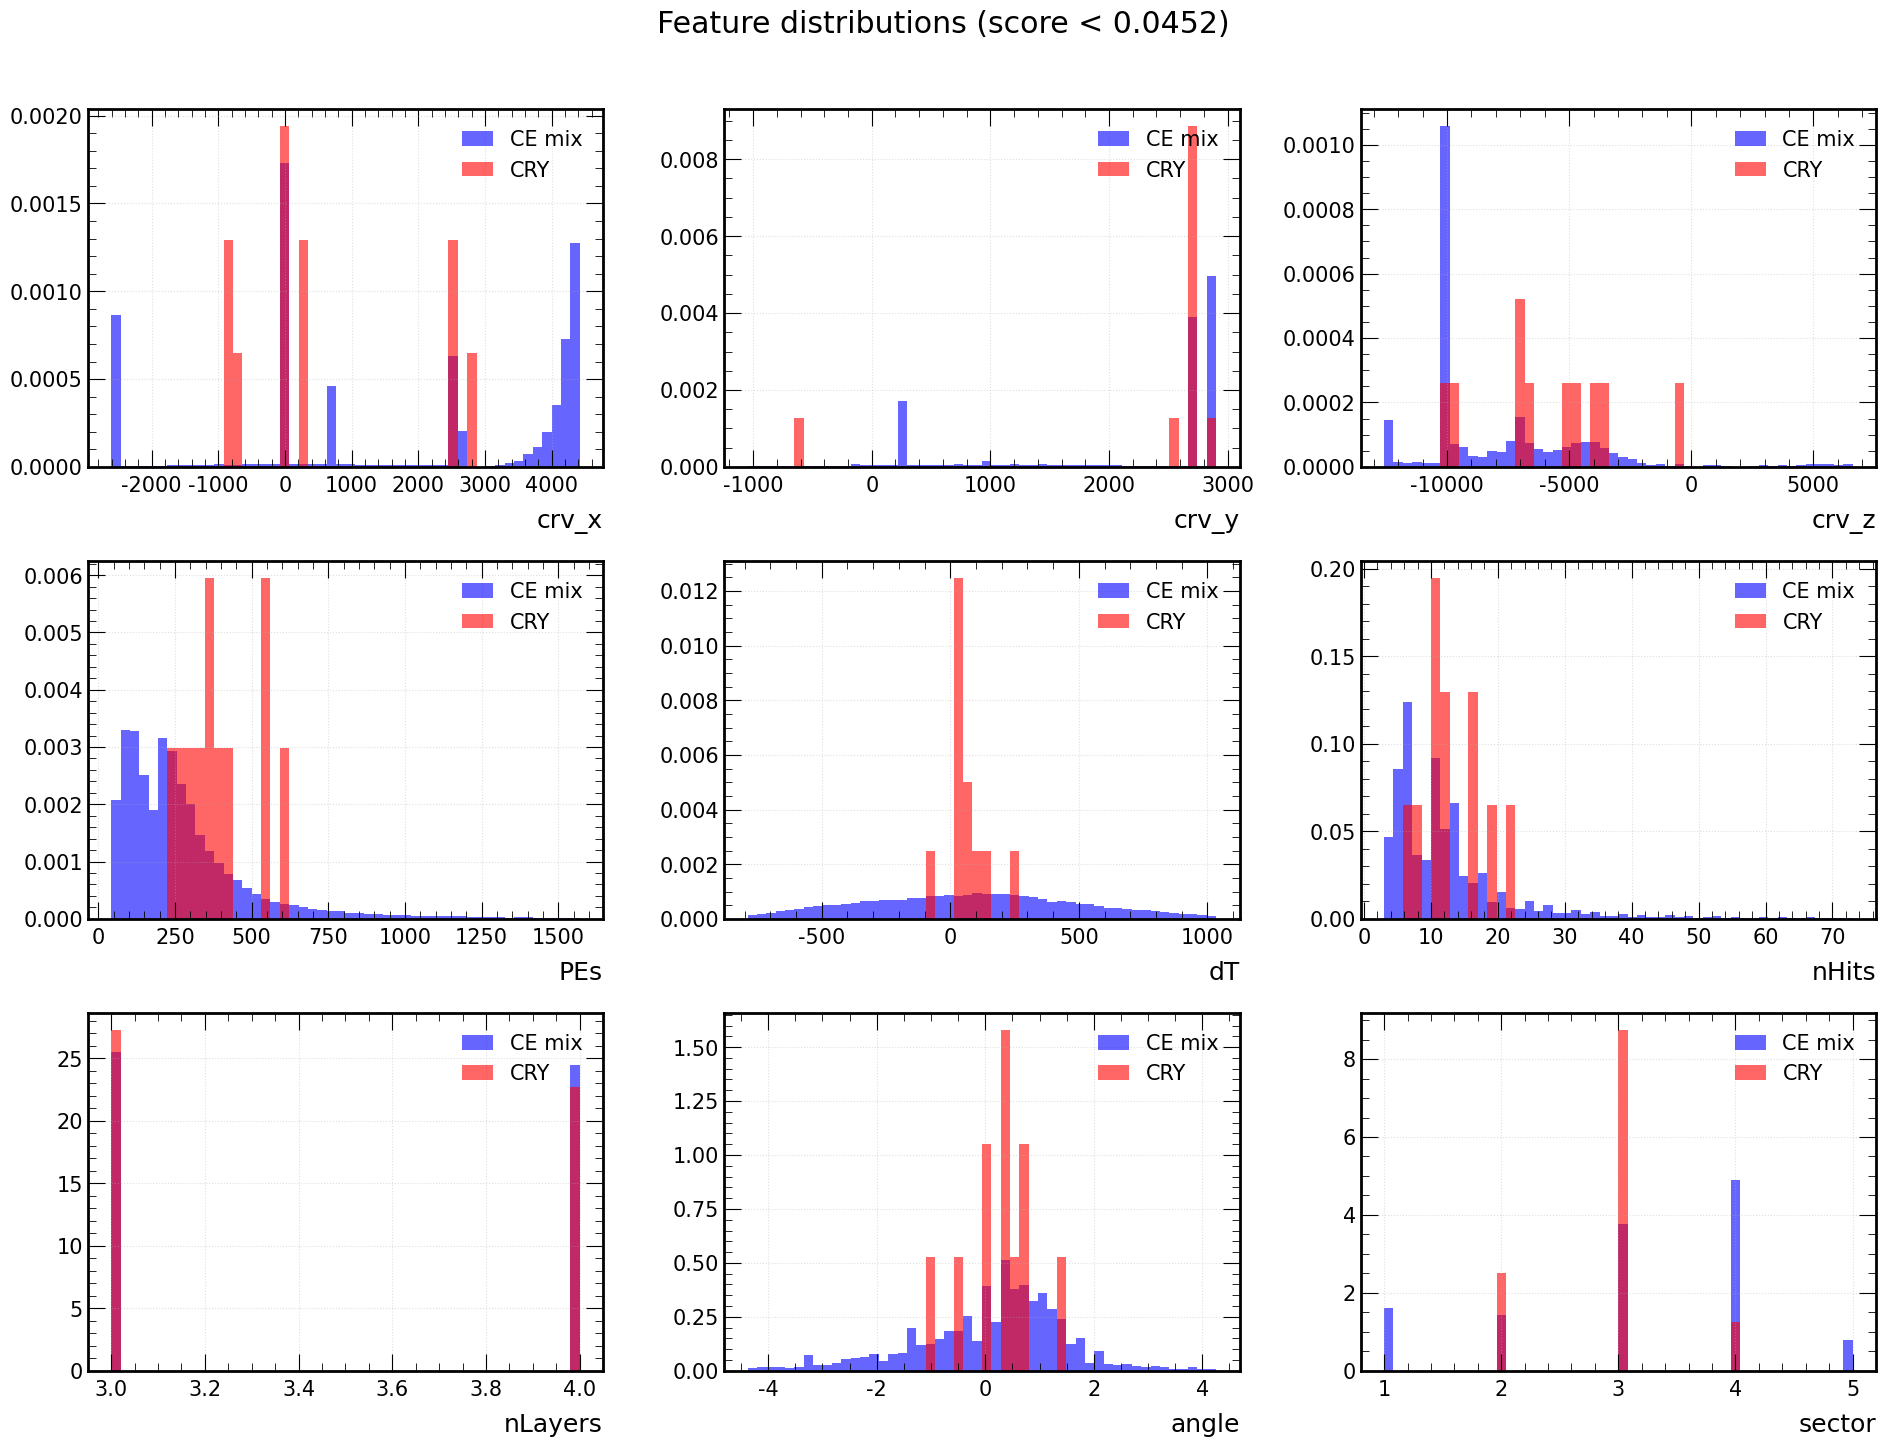

Test dataset:
[AnaModel] [OK] Saved comparison tables to ../../output/images/ml/j/xgb_baseline


,Category,ML model,dT cut,Difference
0,True Positives (CRY vetoed),3967,3967,0
1,True Negatives (CE mix passed),59382,52849,6533
2,False Positives (CE mix vetoed),85,6618,-6533
3,False Negatives (CRY passed),3,3,0


,Metric,ML model,"dT cut [0, 150] ns",Difference,Description
0,Veto efficiency,99.924%,99.924%,+0.000%,Fraction of cosmics vetoed
1,Deadtime,0.143%,11.129%,-10.986%,Fraction of CE mix vetoed
2,Veto purity,97.902%,37.478%,+60.425%,"Of vetoed events, fraction that are cosmics"
3,Overall accuracy,99.861%,89.563%,+10.298%,Overall correct classification rate
4,Figure of merit,99.782%,88.804%,+10.978%,eff_veto * (1 - deadtime)


Full dataset:
[AnaModel] [OK] Saved comparison tables to ../../output/images/ml/j/xgb_baseline


,Category,ML model,dT cut,Difference
0,True Positives (CRY vetoed),19566,19564,2
1,True Negatives (CE mix passed),297170,264758,32412
2,False Positives (CE mix vetoed),439,32851,-32412
3,False Negatives (CRY passed),8,10,-2


,Metric,ML model,"dT cut [0, 150] ns",Difference,Description
0,Veto efficiency,99.959%,99.949%,+0.010%,Fraction of cosmics vetoed
1,Deadtime,0.148%,11.038%,-10.891%,Fraction of CE mix vetoed
2,Veto purity,97.806%,37.325%,+60.480%,"Of vetoed events, fraction that are cosmics"
3,Overall accuracy,99.859%,89.640%,+10.219%,Overall correct classification rate
4,Figure of merit,99.812%,88.916%,+10.895%,eff_veto * (1 - deadtime)


In [6]:
# Now test/validate the model 
from analyse_model import AnaModel
ana = AnaModel(training_results)
ana.print_summary()
ana.plot_feature_importance()
ana.plot_roc(show=True)
threshold_results = ana.find_threshold(show=False)

ana.plot_score_distribution(threshold=threshold_results["threshold"])

ana.plot_physics_by_score(
    df_full=data["df_full"],
    threshold=threshold_results["threshold"],
    above=True
)

ana.plot_physics_by_score(
    df_full=data["df_full"],
    threshold=threshold_results["threshold"],
    above=False
)

print("Test dataset:")
money_test = ana.money_table(
    X=data["X_test"],
    y=data["y_test"],
    metadata=data["metadata_test"],
    threshold=threshold_results["threshold"]
)
display(money_test["confusion"])
display(money_test["metrics"])

print("Full dataset:")
money_full = ana.money_table(
    X=data["df_full"][ana.feature_names],
    y=data["df_full"]["label"],
    metadata=data["df_full"][["subrun", "event"]],
    threshold=threshold_results["threshold"]
)
display(money_full["confusion"])
display(money_full["metrics"])